## Script to find ROIs in muscle imaging data by NMF

Images too big for NMF, so will interatively cut sections off and run NMF
NMF works great to separate rois with large spatial overlap in both space and time. It doesn't produce binary ROIs though

Original dataset collected by Leandre Dubois (and Victor Stimpfling)



In [ ]:
import cv2
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF


In [3]:
pupa_num = 1  # set pupa number (1, 2, etc.)
rec_num = 59  # set recording number

SAVE_NAME = f'TEST_section_legs_pupa{pupa_num}-rec{rec_num}'

hz = 40

In [4]:
# get list of recordings sorted by number 
# (recoring# is not zero-padded in the folder names)
main_path = '/mnt/upramdya_data/MA/Development_project/LD'
pupa_path = os.path.join(main_path, f'pupa_{pupa_num}')
recording_list = os.listdir(pupa_path)

# remove any non-recording files
recording_list = [f for f in recording_list if 'recording' in f]

def extract_recording_number(filename):
    # 1. Remove the 'recording' prefix
    part_after_prefix = filename.split('recording', 1)[1]
    # 2. Extract the number up to the next underscore
    number_string = part_after_prefix.split('_', 1)[0]
    # 3. Convert the extracted string to an integer
    return int(number_string)

recording_list.sort(key=extract_recording_number)

In [5]:
# get last recording folder (most active) and get average image to mask from
recording = recording_list[rec_num]
recording_path = os.path.join(pupa_path, recording)
print(recording)

h5_file = os.path.join(recording_path, 'video_raw.h5')

# get average image of first 100 frames
with h5py.File(h5_file, 'r') as f:
    # Access the data you need from the HDF5 file
    frames = f['frames'][:]
    ave = np.mean(frames[0:100], axis=0)


recording59_22032025_0411


In [6]:
def imshow_flip(image, ax=None, *args, **kwargs):
    if ax is None:
        plt.imshow(image, *args, **kwargs)
        ax = plt.gca()
    else:
        ax.imshow(image, *args, **kwargs)
    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.axis('off')


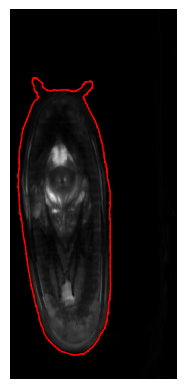

In [7]:
# mask to keep only the pupa

# threshold
thresh = 30
mask = (ave > thresh).astype(np.uint8) * 255

# find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# keep largest contour
contour = max(contours, key=cv2.contourArea)

# plot
plt.figure()
imshow_flip(ave, cmap='gray', vmin=30, vmax=130)
plt.plot(contour[:, 0, 0], contour[:, 0, 1], 'r', linewidth=1)
plt.show()

In [8]:
# get the bounding box of the contour (to only keep area for PCA)
x, y, w, h = cv2.boundingRect(contour)
print(f"Bounding box: x_0={x}, y_0={y}, width={w}, height={h}")

Bounding box: x_0=339, y_0=124, width=486, height=1443


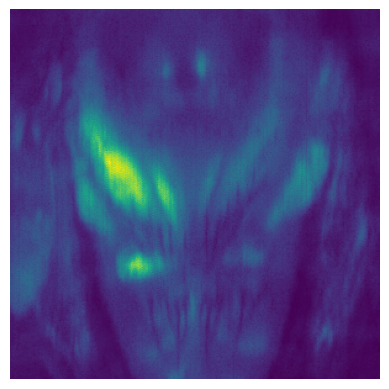

In [9]:
# SELECT ONE AREA FOR PCA TESTING

h1 = 300
w1 = 300
x1 = 435
y1 = 780

area1 = ave[y1:y1+h1, x1:x1+w1]

imshow_flip(area1)
plt.show()

In [11]:
# mask frames to only keep small area
frames_masked = frames[:, y1:y1+h1, x1:x1+w1]

# Flatten frames
num_frames = frames_masked.shape[0]
frames_flat = frames_masked.reshape(num_frames, -1)
print(frames_flat.shape) # MAX for computer about 140'000 pixels


(4799, 90000)


In [15]:
# get shape of selected region (frames_masked) and number of pixels
T, X, Y = frames_masked.shape
N = X * Y

In [16]:
# flaten frames_masked (pixels x time)
frames_flat = frames_masked.reshape(T, N).T

In [19]:
n_components = 20

nmf = NMF(n_components=n_components, init='nndsvda', max_iter=2000)
spatial_comp = nmf.fit_transform(frames_flat)  # spatial
temporal_comp = nmf.components_          # temporal


In [20]:
# reshape spatial maos to original shape
spatial_comp_reconstructed = spatial_comp.T.reshape(n_components, Y, X)
print(spatial_comp_reconstructed.shape)

(20, 300, 300)


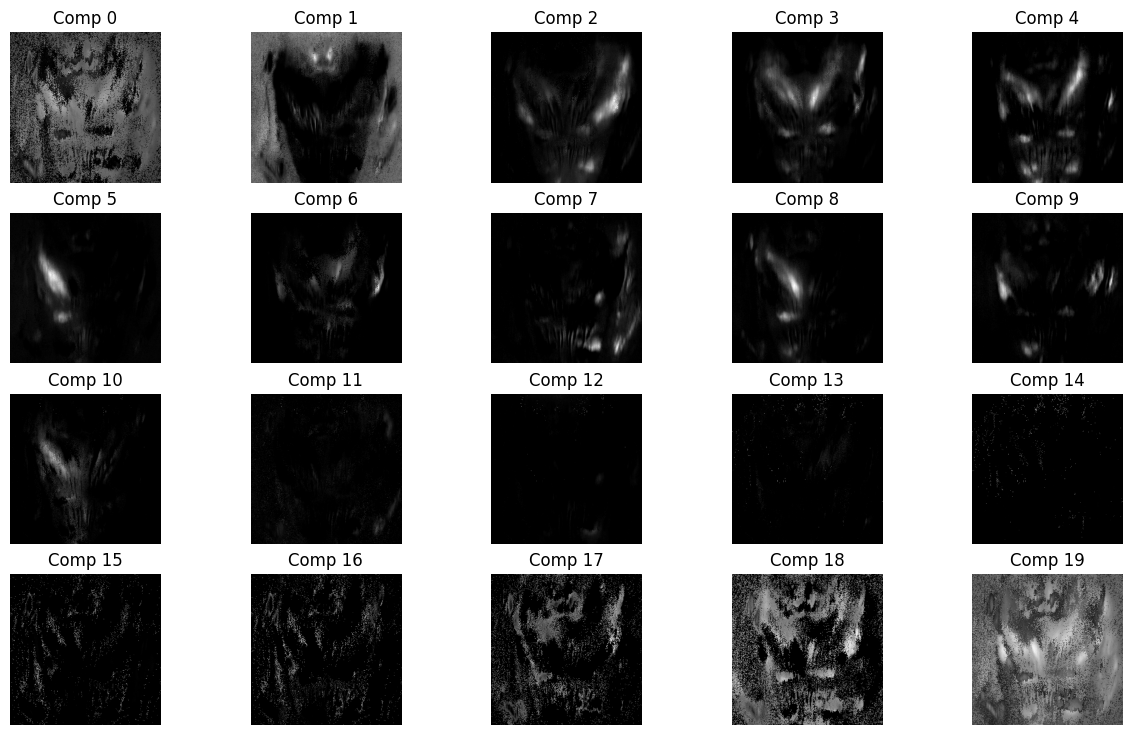

In [21]:
# plot top components
fig, axes = plt.subplots(4, 5, figsize=(15, 9))
axes = axes.flatten()
for i in range(min(n_components, len(axes))):
    imshow_flip(spatial_comp_reconstructed[i], axes[i], cmap='gray')
    axes[i].set_title(f'Comp {i}')
    axes[i].axis('off')

# save figure
save_path = os.path.join(recording_path, f'MNF_spatial_comp_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()

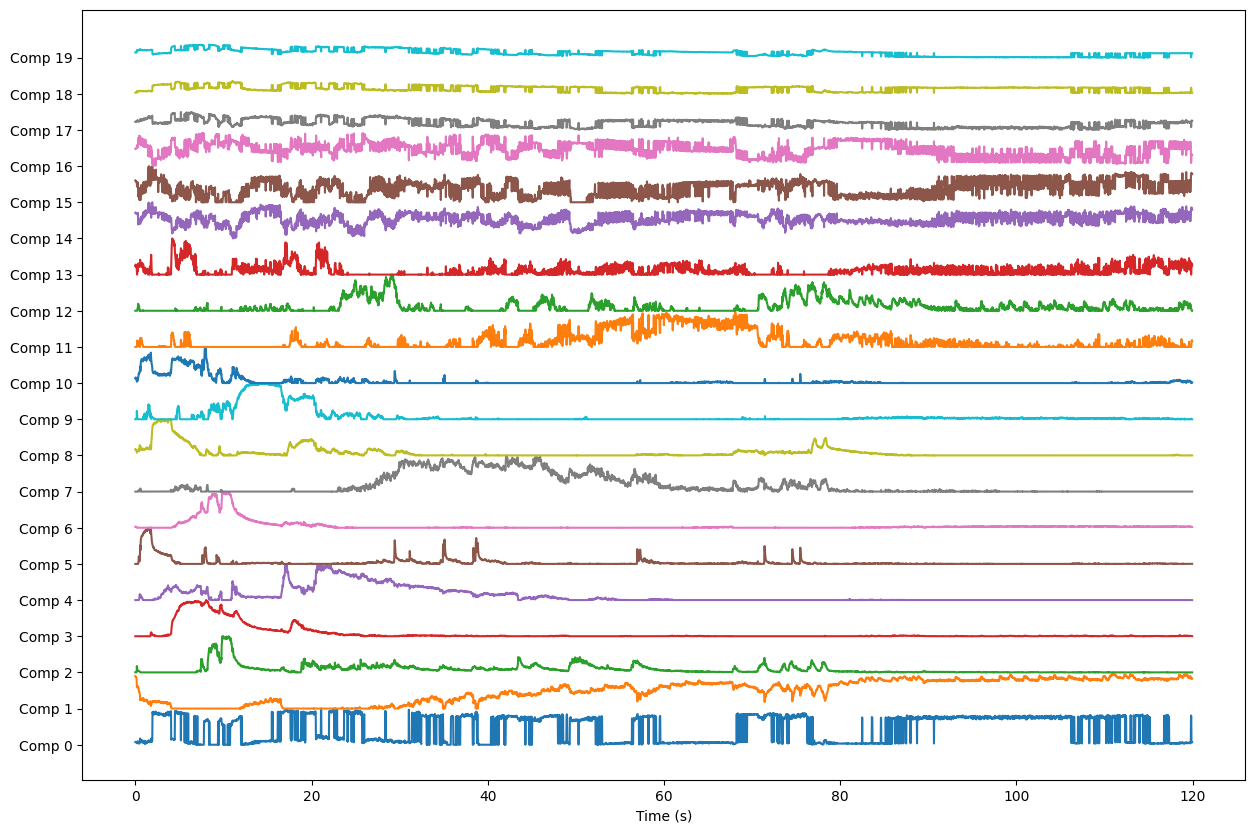

In [22]:
# plot all components in time above each other
t = np.arange(temporal_comp.shape[1])/hz
plt.figure(figsize=(15, 10))
for c in range(n_components):
    H_temp = (temporal_comp[c] - np.min(temporal_comp[c])) / np.max(temporal_comp[c])
    plt.plot(t, H_temp + c*1)  # offset each component for visibility
plt.xlabel('Time (s)')
plt.yticks(range(n_components), [f'Comp {i}' for i in range(n_components)])

save_path = os.path.join(recording_path, f'MNF_time_comp_{SAVE_NAME}.png')
plt.savefig(save_path)

#plt.xlim([60,80])
#plt.ylim([-1, 25])

plt.show()

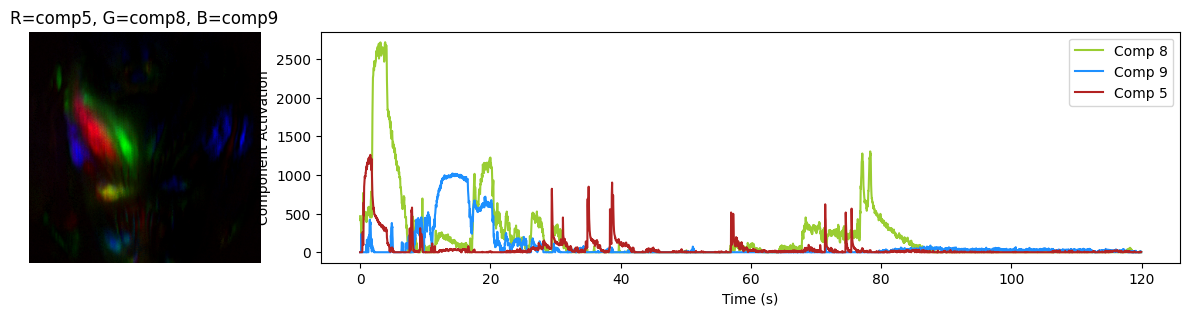

In [23]:
# overlay 3 components in RGB
comp_indices = [5, 8, 9]  # indices of components to use

rgb_image = np.zeros((h1, w1, 3), dtype=np.float32)
# #add area1 to rgb as white background (add to all 3 channels)
# norm = (area1 - area1.min()) / (area1.max() - area1.min())
# rgb_image += norm[..., None]
for i, comp_idx in enumerate(comp_indices):
    comp = spatial_comp_reconstructed[comp_idx]
    # Normalize component to [0, 1]
    comp_norm = (comp - np.min(comp)) / (np.max(comp) - np.min(comp))
    rgb_image[:, :, i] += comp_norm
    # clip to max 1
rgb_image = np.clip(rgb_image, 0, 1)

plt.figure(figsize=(15,3))
plt.subplot(1,4,1)
imshow_flip(rgb_image)
plt.title(f'R=comp{comp_indices[0]}, G=comp{comp_indices[1]}, B=comp{comp_indices[2]}')

plt.subplot2grid((1, 4), (0, 1), colspan=3)
plt.plot(t, temporal_comp[comp_indices[1]], label=f'Comp {comp_indices[1]}', color='yellowgreen')
plt.plot(t, temporal_comp[comp_indices[2]], label=f'Comp {comp_indices[2]}', color='dodgerblue')
plt.plot(t, temporal_comp[comp_indices[0]], label=f'Comp {comp_indices[0]}', color='firebrick')
plt.xlabel('Time (s)')
plt.ylabel('Component Activation')
plt.legend()
#plt.xlim([0, 10])

#plt.vlines(71.43, 0, 1000, colors='k', linestyles='dashed')

# save figure
save_path = os.path.join(recording_path, f'MNF_RGB_overlay_{SAVE_NAME}.png')
plt.savefig(save_path)

plt.show()